# Method 3: Incorporation of Adjacency Constraint with Manual Assignment of Northern Districts

## Method Details:

#### Objective Function:

- Minimize the lack of compactness (a.k.a, the sum of distances between counties that are assigned to the same district).

#### Constraints:

1. **One-County-One-District:** Each county should be assigned to exactly one district.
2. **Ideal Population:** The population in each district should be approximately equal (+- 20%) to the ideal district population size.
3. **Adjacency:** Each county in a district should be adjacency to at least one of the other counties also in that district.

#### The 3 Large Population Counties Consideration
Given that there are three counties that contain very high population around Detroit, these districts will manuaglly be assigned to their own districts.

***Approach to this consideration***
1. **Adjust the Dataset**
- Remove the three large counties, Macomb, Oakland, and Wayne from the dataset, since they will manually be assigned to their own districts.
2. **Adjust the number of districts and recalculate the average distict population**
- Since we are removing the three largest counties, we will be to recalculate the average size we want our disticts to be based on the remaining counties.
3. **Modify and Re-run the Model**
- An additional modification I made when re-running this model, what I adjusted the district population constraint to be +/- 20%. This was the only way I was able to find an optimal solution.

#### Manual Assignment of Northern Most Counties into Districts

**Manual Assignment of District 11: (Most Northern Counties)**
1. Alger
2. Baraga
3. Chippewa
4. Delta
5. Dickinson
6. Gogebic
7. Houghton
8. Iton
9. Keweenaw
10. Luce
11. Mackinac
12. Marquette
13. Menominee
14. Ontonagan
15. Schoolcraft
- Total population: 301397

**Manual Assignment of District 10: (2nd Most Northwen Counties)**
1. Emmet
2. Cheboygan
3. Presque Isle
4. Charlevoix
5. Antrim
6. Otsego
7. Montomorency
8. Alpena
- Total population: 188066


### Step 1: Load necessary libraries

In [1]:
# Import necessary libraries
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt   
import pandas as pd 
from math import pi, pow, sin, cos, asin, sqrt, floor
from pulp import *

### Step 2: Read in the Excel file and GeoJSON file
- Then merge the two data sources to have a comprehensive dataset.
    - In the 'michigan_counties' dataframe, the county name column is 'county_names', and in the 'michigan_counties_geojson' datafram, the county name column is 'name'.

In [2]:
# Read in the Excel file of Michigan counties
xlsx_file_path = '/Users/stefanjenss/Desktop/DataScience/Decision_analytics/Module6/michigan_counties_mod.xlsx'
michigan_counties = pd.read_excel(xlsx_file_path)

# Read in the GeoJSON file of Michigan county boundaries
geojson_file_path = '/Users/stefanjenss/Desktop/DataScience/Decision_analytics/Module6/michigan_counties_mod.geojson'
michigan_counties_geojson = gpd.read_file(geojson_file_path)

print(michigan_counties.head())
print("")
print(michigan_counties_geojson.head())

   count_id county_names   latitude  longitude  pop2020
0         0     Leelanau  45.151771 -86.038496    22870
1         1      Clinton  42.943652 -84.601517    79748
2         2      Wexford  44.338367 -85.578414    34196
3         3       Branch  41.916119 -85.059044    44531
4         4        Ionia  42.945094 -85.074603    66809

                                    geo_point_2d statefp countyfp  countyns  \
0   {'lon': -86.0384960523, 'lat': 45.151770859}      26      089  01622987   
1  {'lon': -84.6015165533, 'lat': 42.9436523662}      26      037  01622961   
2  {'lon': -85.5784138137, 'lat': 44.3383668115}      26      165  01623023   
3  {'lon': -85.0590443604, 'lat': 41.9161186535}      26      023  01622954   
4  {'lon': -85.0746031181, 'lat': 42.9450938315}      26      067  01622976   

   geoid      name         namelsad stusab lsad classfp  ... cbsafp metdivfp  \
0  26089  Leelanau  Leelanau County     MI   06      H1  ...  45900     None   
1  26037   Clinton   Clinton

In [3]:
michigan_counties['county_names'].unique()

array(['Leelanau', 'Clinton', 'Wexford', 'Branch', 'Ionia', 'Mecosta',
       'Keweenaw', 'Isabella', 'Schoolcraft', 'Crawford', 'St.Clair',
       'Missaukee', 'PresqueIsle', 'Saginaw', 'Houghton', 'VanBuren',
       'Ottawa', 'Berrien', 'Montmorency', 'Shiawassee', 'Otsego',
       'Lenawee', 'Newaygo', 'Roscommon', 'Marquette', 'Alger', 'Iron',
       'Barry', 'Emmet', 'Osceola', 'Antrim', 'Jackson', 'Manistee',
       'Calhoun', 'Tuscola', 'Gladwin', 'Menominee', 'Ontonagon',
       'Gogebic', 'Macomb', 'Midland', 'Kent', 'St.Joseph', 'Ogemaw',
       'Oceana', 'Iosco', 'Alpena', 'Sanilac', 'Oscoda', 'Washtenaw',
       'Kalamazoo', 'Ingham', 'Dickinson', 'Bay', 'Benzie', 'Huron',
       'Clare', 'Luce', 'Genesee', 'Montcalm', 'Cheboygan', 'Eaton',
       'Chippewa', 'Lake', 'Kalkaska', 'Mason', 'Mackinac', 'Oakland',
       'Monroe', 'Allegan', 'Wayne', 'Muskegon', 'Gratiot',
       'GrandTraverse', 'Baraga', 'Delta', 'Hillsdale', 'Cass', 'Lapeer',
       'Arenac', 'Charlevoix', '

In [4]:
michigan_counties_geojson['name'].unique()

array(['Leelanau', 'Clinton', 'Wexford', 'Branch', 'Ionia', 'Mecosta',
       'Keweenaw', 'Isabella', 'Schoolcraft', 'Crawford', 'St.Clair',
       'Missaukee', 'PresqueIsle', 'Saginaw', 'Houghton', 'VanBuren',
       'Ottawa', 'Berrien', 'Montmorency', 'Shiawassee', 'Otsego',
       'Lenawee', 'Newaygo', 'Roscommon', 'Marquette', 'Alger', 'Iron',
       'Barry', 'Emmet', 'Osceola', 'Antrim', 'Jackson', 'Manistee',
       'Calhoun', 'Tuscola', 'Gladwin', 'Menominee', 'Ontonagon',
       'Gogebic', 'Macomb', 'Midland', 'Kent', 'St.Joseph', 'Ogemaw',
       'Oceana', 'Iosco', 'Alpena', 'Sanilac', 'Oscoda', 'Washtenaw',
       'Kalamazoo', 'Ingham', 'Dickinson', 'Bay', 'Benzie', 'Huron',
       'Clare', 'Luce', 'Genesee', 'Montcalm', 'Cheboygan', 'Eaton',
       'Chippewa', 'Lake', 'Kalkaska', 'Mason', 'Mackinac', 'Oakland',
       'Monroe', 'Allegan', 'Wayne', 'Muskegon', 'Gratiot',
       'GrandTraverse', 'Baraga', 'Delta', 'Hillsdale', 'Cass', 'Lapeer',
       'Arenac', 'Charlevoix', '

In [5]:
# Merge the two dataframes on the county name
michigan_counties_merged = michigan_counties.merge(michigan_counties_geojson, left_on='county_names', right_on='name', how='inner')
michigan_counties_merged.head()

,count_id,county_names,latitude,longitude,pop2020,geo_point_2d,statefp,countyfp,countyns,geoid,...,cbsafp,metdivfp,funcstat,aland,awater,intptlat,intptlon,state_name,countyfp_nozero,geometry
0,0,Leelanau,45.151771,-86.038496,22870,"{'lon': -86.0384960523, 'lat': 45.151770859}",26,089,01622987,26089,...,45900,None,A,899241895,5659105307,+45.1461816,-086.0515740,Michigan,89,"POLYGON ((-85.56175 44.95226, -85.56209 44.950..."
1,1,Clinton,42.943652,-84.601517,79748,"{'lon': -84.6015165533, 'lat': 42.9436523662}",26,037,01622961,26037,...,29620,None,A,1467017475,21098128,+42.9504550,-084.5916949,Michigan,37,"POLYGON ((-84.83762 43.03264, -84.83754 43.032..."
2,2,Wexford,44.338367,-85.578414,34196,"{'lon': -85.5784138137, 'lat': 44.3383668115}",26,165,01623023,26165,...,15620,None,A,1463148726,27182043,+44.3313751,-085.5700462,Michigan,165,"POLYGON ((-85.81909 44.42450, -85.81910 44.425..."
3,3,Branch,41.916119,-85.059044,44531,"{'lon': -85.0590443604, 'lat': 41.9161186535}",26,023,01622954,26023,...,17740,None,A,1311605515,34420092,+41.9184551,-085.0668852,Michigan,23,"POLYGON ((-85.29293 41.98482, -85.29293 41.984..."
4,4,Ionia,42.945094,-85.074603,66809,"{'lon': -85.0746031181, 'lat': 42.9450938315}",26,067,01622976,26067,...,24340,None,A,1479710906,22590318,+42.9446503,-085.0737660,Michigan,67,"POLYGON ((-85.07503 43.12021, -85.06470 43.120..."


### Step 3: Calculate the Distance Between County Pairs

In [6]:
# Define function to calculate distance between two sets of longitudes / latitudes

# Function to convert degrees to radians
def degrees_to_radians(x):
    return((pi / 180) * x)

# Function to calculate distance between two points on a sphere (in miles) given their longitudes and latitudes
def lon_lat_distance_miles(lon_a, lat_a, lon_b, lat_b):
    """
    Calculates the great-circle distance between two points on a sphere given their longitudes and latitudes.
    
    Parameters:
    lon_a (float): longitude of point A in degrees
    lat_a (float): latitude of point A in degrees
    lon_b (float): longitude of point B in degrees
    lat_b (float): latitude of point B in degrees
    
    Returns:
    float: distance between the two points in miles
    """
    radius_of_earth = 24872 / (2 * pi)
    c = sin((degrees_to_radians(lat_a) - \
    degrees_to_radians(lat_b)) / 2)**2 + \
    cos(degrees_to_radians(lat_a)) * \
    cos(degrees_to_radians(lat_b)) * \
    sin((degrees_to_radians(lon_a) - \
    degrees_to_radians(lon_b))/2)**2
    return(2 * radius_of_earth * (asin(sqrt(c))))

# Function to convert the distance between two points on a sphere (in miles) to meters
def lon_lat_distance_meters (lon_a, lat_a, lon_b, lat_b):
    return(lon_lat_distance_miles(lon_a, lat_a, lon_b, lat_b) * 1609.34)

In [7]:
# Remove population to allow easy joining of long and lat for each county pair
lat_lon = ['county_names', 'latitude', 'longitude']
lat_lon = michigan_counties_merged[lat_lon]

# Create list of county names for pairing        
county_names = michigan_counties['county_names'].to_numpy()

# Create each unique pair
pairs = []

# Loop through each county name and create a pair with each other county name
for i in range(len(county_names)):
    for j in range(i + 1, len(county_names)):
        pairs.append((county_names[i], county_names[j]))

# Create column names for county pairs df
col_names = ['county_1', 'county_2']

# Create df of county pairs                
county_pairs = pd.DataFrame(pairs, columns = col_names)

 # Add first county longitude and latitude
county_pairs = county_pairs.merge(lat_lon, left_on = 'county_1', right_on = 'county_names', how = 'left')
county_pairs.drop('county_names', axis = 1, inplace = True) # Drop county names column
county_pairs = county_pairs.rename(columns={'latitude': 'county_1_lat', 'longitude': 'county_1_long'}) # Rename columns

# Add second county longitude and latitude
county_pairs = county_pairs.merge(lat_lon, left_on = 'county_2', right_on = 'county_names', how = 'left')
county_pairs.drop('county_names', axis = 1, inplace = True) # Drop county names column
county_pairs = county_pairs.rename(columns={'latitude': 'county_2_lat', 'longitude': 'county_2_long'}) # Rename columns

# Add distance between each county pair in miles and meters;
distance_miles = [] # Create empty list to store distance in miles
distance_meters = [] # Create empty list to store distance in meters

# Loop through each county pair and calculate distance in miles and meters
for i in range(len(county_pairs)):
    distance_miles.append(lon_lat_distance_miles(county_pairs.iloc[i, 2], county_pairs.iloc[i, 3], county_pairs.iloc[i, 4], county_pairs.iloc[i, 5]))
    distance_meters.append(lon_lat_distance_meters(county_pairs.iloc[i, 2], county_pairs.iloc[i, 3], county_pairs.iloc[i, 4], county_pairs.iloc[i, 5]))

# Add distance columns to county pairs df
county_pairs['distance_miles'] = distance_miles
county_pairs['distance_meters'] = distance_meters

# Check table
county_pairs

,county_1,county_2,county_1_lat,county_1_long,county_2_lat,county_2_long,distance_miles,distance_meters
0,Leelanau,Clinton,45.151771,-86.038496,42.943652,-84.601517,100.038253,160995.562830
1,Leelanau,Wexford,45.151771,-86.038496,44.338367,-85.578414,32.050066,51579.452482
2,Leelanau,Branch,45.151771,-86.038496,41.916119,-85.059044,69.831366,112382.410744
3,Leelanau,Ionia,45.151771,-86.038496,42.945094,-85.074603,67.621439,108825.886417
4,Leelanau,Mecosta,45.151771,-86.038496,43.640768,-85.324634,49.938224,80367.581755
...,...,...,...,...,...,...,...,...
3398,Arenac,Alcona,44.042885,-83.747242,44.683623,-83.129008,43.010988,69219.303841
3399,Arenac,Livingston,44.042885,-83.747242,42.602917,-83.911528,15.593543,25095.312007
3400,Charlevoix,Alcona,45.502498,-85.373250,44.683623,-83.129008,155.151831,249692.047763
3401,Charlevoix,Livingston,45.502498,-85.373250,42.602917,-83.911528,102.674475,165238.138922


### Step 4: Create an adjacency dictionary for Michigan counties from an existing adjacency .txt file from the census website

4.1 Read in the .txt file with the adjacency information

In [8]:
# Read in the .txt file of county adjacencies
txt_file_path = '/Users/stefanjenss/Desktop/DataScience/Decision_analytics/Module6/county_adjacency_mod.txt'

4.2 Store the Michican counties and their adjaciencies into a list

In [9]:
# Extracting the adjacencies for Michigan counties

# Parse the file to extract adjacencies for Michigan counties
adjacency_data = {}
current_county = None

with open(txt_file_path, 'r') as file:
    for line in file:
        # Split the line based on tab delimiter
        parts = line.split('\t')
        # If the line contains a county name, update the current county
        if parts[0]:
            current_county_name = parts[0].replace('"', '').strip()
            # Check if the county is from Michigan
            if "MI" in current_county_name:
                current_county = current_county_name
                adjacency_data[current_county] = []
        # If there's a current county from Michigan, append the adjacent counties to it
        elif current_county:
            adjacent_county_name = parts[2].replace('"', '').strip()
            if "MI" in adjacent_county_name:  # Only consider MI counties as adjacent
                adjacency_data[current_county].append(adjacent_county_name)

# Display the first few entries for inspection
list(adjacency_data.items())[0:3]


[('Alcona County, MI',
  ['Alpena County, MI',
   'Iosco County, MI',
   'Montmorency County, MI',
   'Ogemaw County, MI',
   'Oscoda County, MI']),
 ('Alger County, MI',
  ['Delta County, MI',
   'Keweenaw County, MI',
   'Luce County, MI',
   'Marquette County, MI',
   'Schoolcraft County, MI']),
 ('Allegan County, MI',
  ['Allegan County, MI',
   'Barry County, MI',
   'Kalamazoo County, MI',
   'Kent County, MI',
   'Ottawa County, MI',
   'VanBuren County, MI'])]

4.3 Modify this list so that only the county name e.g., "Alcona", and not the full name, e.g., "Alcona County, MI"

In [10]:
# Modifying the adjacency dictionary to retain only the county name
modified_adjacency_dict = {}

for full_name, adjacents in adjacency_data.items():
    county_name = full_name.split()[0].replace('"', '')
    modified_adjacency_dict[county_name] = [adj.split()[0].replace('"', '') for adj in adjacents]

# Checking the first few entries in the modified adjacency dictionary
list(modified_adjacency_dict.items())


[('Alcona', ['Alpena', 'Iosco', 'Montmorency', 'Ogemaw', 'Oscoda']),
 ('Alger', ['Delta', 'Keweenaw', 'Luce', 'Marquette', 'Schoolcraft']),
 ('Allegan', ['Allegan', 'Barry', 'Kalamazoo', 'Kent', 'Ottawa', 'VanBuren']),
 ('Alpena', ['Alpena', 'Montmorency', 'Oscoda', 'PresqueIsle']),
 ('Antrim',
  ['Charlevoix',
   'Crawford',
   'GrandTraverse',
   'Kalkaska',
   'Leelanau',
   'Otsego']),
 ('Arenac', ['Bay', 'Gladwin', 'Huron', 'Iosco', 'Ogemaw']),
 ('Baraga', ['Houghton', 'Iron', 'Marquette']),
 ('Barry', ['Barry', 'Calhoun', 'Eaton', 'Ionia', 'Kalamazoo', 'Kent']),
 ('Bay', ['Bay', 'Gladwin', 'Huron', 'Midland', 'Saginaw', 'Tuscola']),
 ('Benzie', ['GrandTraverse', 'Leelanau', 'Manistee', 'Wexford']),
 ('Berrien', ['Berrien', 'Cass', 'VanBuren']),
 ('Branch', ['Branch', 'Calhoun', 'Hillsdale', 'Kalamazoo', 'St.Joseph']),
 ('Calhoun',
  ['Branch',
   'Calhoun',
   'Eaton',
   'Hillsdale',
   'Jackson',
   'Kalamazoo',
   'St.Joseph']),
 ('Cass', ['Berrien', 'Cass', 'Kalamazoo', 'St.J

#### 4.4 Create the adjacency matrix for Michigan Counties

In [11]:
# Create an adjacency matrix for Michigan counties and their adjacent counties using the modified adjacency dictionary
adjacency_matrix = pd.DataFrame(0, index = county_names, columns = county_names)

for county, adjacents in modified_adjacency_dict.items():
    for adjacent in adjacents:
        adjacency_matrix.loc[county, adjacent] = 1

# Display the first few rows of the adjacency matrix
adjacency_matrix.head()

,Leelanau,Clinton,Wexford,Branch,Ionia,Mecosta,Keweenaw,Isabella,Schoolcraft,Crawford,...,GrandTraverse,Baraga,Delta,Hillsdale,Cass,Lapeer,Arenac,Charlevoix,Alcona,Livingston
Leelanau,1,0,0,0,0,0,0,0,1,0,...,1,0,1,0,0,0,0,1,0,0
Clinton,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Wexford,1,0,1,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,0,0
Branch,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Ionia,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Step 5: Modify the DataFrame to exclude the counties that will be manually assigned

5.1 Define the parameters for the problem

In [12]:
# Create a dictionary of county names and their populations
county_populations = michigan_counties_merged[['name', 'pop2020']].set_index('name').to_dict()['pop2020']

# Number of counties and districts in Michigan
n_counties = 83
n_districts = 14

5.2 Create lists of the large counties and the northern counites that will be manually assigned to a district

In [13]:
# Create a list of the three large counties
large_counties = ['Wayne', 'Oakland', 'Macomb']

# Create a list of the counties in the upper peninsula of Michigan
northern = ["Alger", "Baraga", "Chippewa", "Delta", "Dickinson", "Gogebic", "Houghton", "Iron", "Keweenaw","Luce", "Mackinac", "Marquette", "Menominee", "Ontonagon", "Schoolcraft", "Emmet", "Cheboygan", "PresqueIsle", "Charlevoix", "Antrim", "Otsego", 
                        "Montmorency", "Alpena" ]

# Create a list of all the manually assigned counties
manual_counties = large_counties + northern #most_northern + second_most_northern

# Create a new dataframe that doesn't contain any of the manual counties
michigan_counties_adjusted = michigan_counties_merged[~michigan_counties_merged['name'].isin(manual_counties)]



5.3 Adjust the number of counties and districts, and calculate the new ideal district population

In [14]:
# Adjust the number of counties and districts in Michigan
n_counties_adjusted = len(michigan_counties_adjusted)
print(n_counties_adjusted)
n_districts_adjusted = n_districts - (len(large_counties) + 1)

print(n_districts_adjusted)

# Approximate population of each district
average_district_population_adjusted = michigan_counties_adjusted['pop2020'].sum() / n_districts_adjusted

print(average_district_population_adjusted)

57
10
564398.1


5.4 Filter the pairs to exclude the manual counties

In [15]:
# Filter the county pairs dataframe to only include counties that are not in the large counties list
county_pairs_adjusted = county_pairs[~county_pairs['county_1'].isin(manual_counties)]

# Create a dictionary of the adjusted county names and their populations
county_populations_adjusted = michigan_counties_adjusted[['name', 'pop2020']].set_index('name').to_dict()['pop2020']
county_names_adjusted = michigan_counties_adjusted['name'].to_numpy()

print(county_names_adjusted)
print(county_names_adjusted.shape)
print(county_populations_adjusted)

['Leelanau' 'Clinton' 'Wexford' 'Branch' 'Ionia' 'Mecosta' 'Isabella'
 'Crawford' 'St.Clair' 'Missaukee' 'Saginaw' 'VanBuren' 'Ottawa' 'Berrien'
 'Shiawassee' 'Lenawee' 'Newaygo' 'Roscommon' 'Barry' 'Osceola' 'Jackson'
 'Manistee' 'Calhoun' 'Tuscola' 'Gladwin' 'Midland' 'Kent' 'St.Joseph'
 'Ogemaw' 'Oceana' 'Iosco' 'Sanilac' 'Oscoda' 'Washtenaw' 'Kalamazoo'
 'Ingham' 'Bay' 'Benzie' 'Huron' 'Clare' 'Genesee' 'Montcalm' 'Eaton'
 'Lake' 'Kalkaska' 'Mason' 'Monroe' 'Allegan' 'Muskegon' 'Gratiot'
 'GrandTraverse' 'Hillsdale' 'Cass' 'Lapeer' 'Arenac' 'Alcona'
 'Livingston']
(57,)
{'Leelanau': 22870, 'Clinton': 79748, 'Wexford': 34196, 'Branch': 44531, 'Ionia': 66809, 'Mecosta': 40720, 'Isabella': 64447, 'Crawford': 13491, 'St.Clair': 160151, 'Missaukee': 15213, 'Saginaw': 188330, 'VanBuren': 75692, 'Ottawa': 300873, 'Berrien': 152900, 'Shiawassee': 68022, 'Lenawee': 98567, 'Newaygo': 50886, 'Roscommon': 23708, 'Barry': 63554, 'Osceola': 23274, 'Jackson': 160066, 'Manistee': 25287, 'Calhoun':

5.5 Create the optimization problem

In [16]:
# Initialize the adjusted model
model1 = LpProblem("Michigan_Redistricting_Adjusted", LpMinimize)

# Decision variable: binary variable indicating whether a county is in a district
x1 = LpVariable.dicts("x_adjusted", ((i, j) for i in county_names_adjusted for j in range(n_districts_adjusted)), cat='Binary')

# Objective function: minimize the deviation of populations in each district from the average population
# Calculate the deviation of populations in each district from the average population
model1 += lpSum(
    ((county_populations_adjusted[county_names_adjusted[i]] - average_district_population_adjusted) *
     (county_populations_adjusted[county_names_adjusted[i]] - average_district_population_adjusted) *
     x1[(county_names_adjusted[i], j)])
    for i in range(len(county_names_adjusted))
    for j in range(n_districts_adjusted)
)

# Constraints
# Constraints: Each county must be assigned to exactly one district
for i in range(len(county_names_adjusted)):
    model1 += lpSum(x1[(county_names_adjusted[i], j)] for j in range(n_districts_adjusted)) == 1

# Adjacency constraint
for i in range(len(county_names_adjusted)):
     for j in range(n_districts_adjusted):
         model1 += lpSum(adjacency_matrix.loc[county_names_adjusted[i], neighbor] * x1[(neighbor, j)] for neighbor in county_names_adjusted) >= x1[(county_names_adjusted[i], j)]

# The population of the district must be within 20% of the average population
for j in range(n_districts_adjusted):
    model1 += lpSum(county_populations_adjusted[county_names_adjusted[i]] * x1[(county_names_adjusted[i], j)] for i in range(len(county_names_adjusted))) >= 0.80 * average_district_population_adjusted
    model1 += lpSum(county_populations_adjusted[county_names_adjusted[i]] * x1[(county_names_adjusted[i], j)] for i in range(len(county_names_adjusted))) <= 1.20 * average_district_population_adjusted

In [17]:
# Solve and print the solution
model1.solve()

# Print the status of the solution
print("Status:", LpStatus[model1.status])

# Print the objective value
print("Objective Function Value:", value(model1.objective))
print("")

# Print the district assignments along with the total district populations on a separate line starting with district 1
for j in range(n_districts_adjusted):
    print("District", j + 1, ":", end = " ")
    district_population = 0
    for i in range(len(county_names_adjusted)):
        if x1[(county_names_adjusted[i], j)].varValue == 1:
            print(county_names_adjusted[i], end = ", ")
            district_population += county_populations_adjusted[county_names_adjusted[i]]
    print("Total Population:", district_population)



# Manually assign the 'northern' counties in the upper peninsula to the same district
print("District 11:", northern)

# Assign the large counties to their own districts starting with district 12
for i in range(len(large_counties)):
    print("District", i + 12, ":", large_counties[i])



Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/stefanjenss/anaconda3/envs/MSDS460/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/t2/xw_g33n96rxfmq14n3dnpb6h0000gn/T/3fc5ac9e85b84d36abde75a52376ded2-pulp.mps timeMode elapsed branch printingOptions all solution /var/folders/t2/xw_g33n96rxfmq14n3dnpb6h0000gn/T/3fc5ac9e85b84d36abde75a52376ded2-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 652 COLUMNS
At line 7353 RHS
At line 8001 BOUNDS
At line 8572 ENDATA
Problem MODEL has 647 rows, 570 columns and 4490 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 1.31138e+13 - 0.00 seconds
Cgl0005I 57 SOS with 570 members
Cgl0004I processed model has 137 rows, 570 columns (570 integer (570 of which binary)) and 1580 elements
Cbc0038I Initial state - 16 integers unsatisfied sum - 3.33793
Cbc0038I Pass   1: suminf.    2.

### Step 6: Visualize the generated districts from the optimization results to get a better understanding of the country partitioning amount districts

In [18]:
# Add a column to the michigan_counties_merged dataframe to store the district assignments
# Create the district column and initialize it to 0
michigan_counties_merged['district'] = 0

# Assign the districts to each county
# Assign the adjusted counties to districts 1 through 11 based on the solution to the adjusted model
for i in range(len(county_names_adjusted)):
    for j in range(n_districts_adjusted):
        if value(x1[(county_names_adjusted[i], j)]) == 1:
            michigan_counties_merged.loc[michigan_counties_merged['name'] == county_names_adjusted[i], 'district'] = j + 1

# Assign the northern counties to district 11
for county in northern:
    michigan_counties_merged.loc[michigan_counties_merged['name'] == county, 'district'] = 11

# Assign the large counties to their own districts starting with district 12
for i in range(len(large_counties)):
    michigan_counties_merged.loc[michigan_counties_merged['name'] == large_counties[i], 'district'] = i + 12

# Display the first few rows of the michigan_counties_merged dataframe
michigan_counties_merged


,count_id,county_names,latitude,longitude,pop2020,geo_point_2d,statefp,countyfp,countyns,geoid,...,metdivfp,funcstat,aland,awater,intptlat,intptlon,state_name,countyfp_nozero,geometry,district
0,0,Leelanau,45.151771,-86.038496,22870,"{'lon': -86.0384960523, 'lat': 45.151770859}",26,089,01622987,26089,...,None,A,899241895,5659105307,+45.1461816,-086.0515740,Michigan,89,"POLYGON ((-85.56175 44.95226, -85.56209 44.950...",10
1,1,Clinton,42.943652,-84.601517,79748,"{'lon': -84.6015165533, 'lat': 42.9436523662}",26,037,01622961,26037,...,None,A,1467017475,21098128,+42.9504550,-084.5916949,Michigan,37,"POLYGON ((-84.83762 43.03264, -84.83754 43.032...",1
2,2,Wexford,44.338367,-85.578414,34196,"{'lon': -85.5784138137, 'lat': 44.3383668115}",26,165,01623023,26165,...,None,A,1463148726,27182043,+44.3313751,-085.5700462,Michigan,165,"POLYGON ((-85.81909 44.42450, -85.81910 44.425...",10
3,3,Branch,41.916119,-85.059044,44531,"{'lon': -85.0590443604, 'lat': 41.9161186535}",26,023,01622954,26023,...,None,A,1311605515,34420092,+41.9184551,-085.0668852,Michigan,23,"POLYGON ((-85.29293 41.98482, -85.29293 41.984...",9
4,4,Ionia,42.945094,-85.074603,66809,"{'lon': -85.0746031181, 'lat': 42.9450938315}",26,067,01622976,26067,...,None,A,1479710906,22590318,+42.9446503,-085.0737660,Michigan,67,"POLYGON ((-85.07503 43.12021, -85.06470 43.120...",7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,78,Lapeer,43.090147,-83.221784,88780,"{'lon': -83.2217837238, 'lat': 43.0901474299}",26,087,01622986,26087,...,47664,A,1675675444,41083140,+43.0886327,-083.2243247,Michigan,87,"POLYGON ((-83.45966 43.14338, -83.45966 43.145...",10
79,79,Arenac,44.042885,-83.747242,15089,"{'lon': -83.7472418424, 'lat': 44.0428854726}",26,011,01622948,26011,...,None,A,940627657,822313309,+44.0368327,-083.7406755,Michigan,11,"POLYGON ((-83.92749 44.16183, -83.92692 44.161...",7
80,80,Charlevoix,45.502498,-85.373250,26293,"{'lon': -85.373250216, 'lat': 45.5024976764}",26,029,01622957,26029,...,None,A,1078288786,2522931119,+45.5131638,-085.4503920,Michigan,29,"POLYGON ((-85.40467 45.20749, -85.42159 45.207...",11
81,81,Alcona,44.683623,-83.129008,10417,"{'lon': -83.1290075152, 'lat': 44.6836233781}",26,001,01622943,26001,...,None,A,1747349266,2890404970,+44.6825347,-082.8340784,Michigan,1,"POLYGON ((-83.88742 44.59538, -83.88742 44.595...",5


In [23]:
# Extract District Assignments
district_assignments = {}
for county in county_names_adjusted:
    for district in range(n_districts_adjusted):
        if x1[(county, district)].varValue == 1:
            district_assignments[county] = district

In [24]:
# Check Contiguity for Each District
import networkx as nx

def is_contiguous(district_counties, adjacency_matrix):
    # Create a graph for the district
    G = nx.Graph()
    for county in district_counties:
        G.add_node(county)
        for neighbor, value in adjacency_matrix.loc[county].items():
            if value and neighbor in district_counties:
                G.add_edge(county, neighbor)

    # If the number of connected components is greater than 1, it's not contiguous
    return nx.number_connected_components(G) == 1

non_contiguous_districts = []
for district in range(n_districts_adjusted):
    district_counties = [county for county, assigned_district in district_assignments.items() if assigned_district == district]
    if not is_contiguous(district_counties, adjacency_matrix):
        non_contiguous_districts.append(district)

print(non_contiguous_districts)


[0, 1, 2, 3, 4, 5, 6, 8, 9]


In [26]:
def reassign_county(county, district_assignments, adjacency_matrix, county_populations, average_district_population):
    # Skip manually assigned counties
    if county not in district_assignments:
        return

    # Get potential neighboring districts
    neighboring_districts = [district_assignments[neighbor] for neighbor, value in adjacency_matrix.loc[county].items() if value and neighbor != county and neighbor in district_assignments]
    
    # Choose the neighboring district where the reassignment causes the least deviation from the average population
    best_district = None
    best_deviation = float('inf')
    for district in neighboring_districts:
        new_population = sum(county_populations[c] for c, d in district_assignments.items() if d == district) + county_populations[county]
        deviation = abs(new_population - average_district_population)
        if deviation < best_deviation and 0.80 * average_district_population <= new_population <= 1.20 * average_district_population:
            best_deviation = deviation
            best_district = district
    
    # Reassign the county
    if best_district is not None:
        district_assignments[county] = best_district

for district in non_contiguous_districts:
    # Get counties in the district
    district_counties = [county for county, assigned_district in district_assignments.items() if assigned_district == district]
    
    # Identify connected components and the smallest component
    G = nx.Graph()
    for county in district_counties:
        G.add_node(county)
        for neighbor, value in adjacency_matrix.loc[county].items():
            if value and neighbor in district_counties:
                G.add_edge(county, neighbor)
    
    components = list(nx.connected_components(G))
    smallest_component = min(components, key=lambda component: sum(county_populations[county] for county in component))
    
    # Reassign counties of the smallest component
    for county in smallest_component:
        reassign_county(county, district_assignments, adjacency_matrix, county_populations, average_district_population_adjusted)


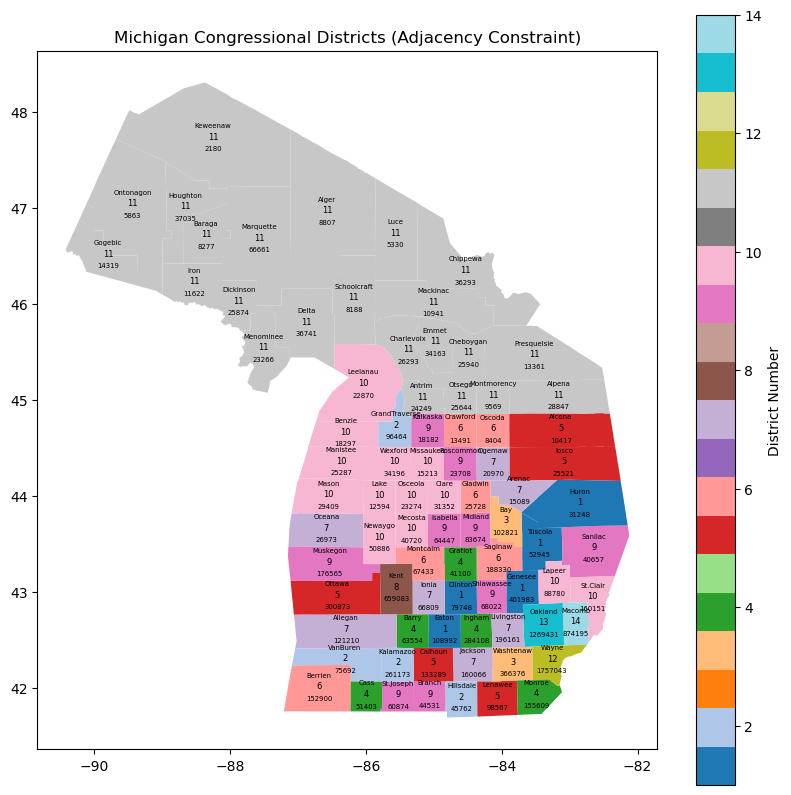

In [27]:
# Ensure that michigan_counties_merged is a GeoDataFrame
geo_michigan_adjacency = gpd.GeoDataFrame(michigan_counties_merged, geometry=gpd.GeoSeries(michigan_counties_merged['geometry']))

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
geo_michigan_adjacency.plot(column='district', ax=ax, legend=True, cmap='tab20', legend_kwds={'label': "District Number"})
ax.set_title('Michigan Congressional Districts (Adjacency Constraint)')

# Annotate each county with its assigned district number
for index, row in geo_michigan_adjacency.iterrows():
    plt.annotate(text=row['district'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y), horizontalalignment='center', fontsize=6)

# Annotate each country with its name
for index, row in geo_michigan_adjacency.iterrows():
    plt.annotate(text=row['name'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y+.12), horizontalalignment='center', fontsize=5)

# Annotate each county with its population
for index, row in geo_michigan_adjacency.iterrows():
    plt.annotate(text=row['pop2020'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y-.12), horizontalalignment='center', fontsize=5)

# Show the plot
plt.show()


5.2 Plot the results

In [ ]:
# Convert the 'geometry' column to a GeoSeries and create a GeoDataFrame
geo_michigan_adjacency = gpd.GeoDataFrame(michigan_counties_merged, geometry=gpd.GeoSeries(michigan_counties_merged['geometry']))

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
geo_michigan_adjacency.plot(column='district', ax=ax, legend=True, cmap='tab20', legend_kwds={'label': "District Number"})
ax.set_title('Michigan Congressional Districts (Adjacency Constraint)')

# Annotate each county with its assigned district number
for index, row in geo_michigan_adjacency.iterrows():
    plt.annotate(text=row['district'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y), horizontalalignment='center', fontsize=6)

# Annotate each country with its name
for index, row in geo_michigan_adjacency.iterrows():
    plt.annotate(text=row['name'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y+.12), horizontalalignment='center', fontsize=5)

# Annotate each county with its population
for index, row in geo_michigan_adjacency.iterrows():
    plt.annotate(text=row['pop2020'], xy=(row['geometry'].centroid.x, row['geometry'].centroid.y-.12), horizontalalignment='center', fontsize=5)

# Show the plot
plt.show()
